## Sanity-check of the method

As a first test, we will stablish the workflow of the dynamic multi-product formulas (DMPF) on the same Heisenberg Hamiltonian given in equation (12) of Niall's paper for a small number of spins.

In [1]:
include("middle_out_contraction.jl")
include("dense_matrix_computation.jl")
include("direct_MPO_computation.jl")
include("product_formula_generation.jl")

using Distributions
using Random

n = 3

Random.seed!(1234)
J =  rand(Uniform(1/4, 3/4), n-1)

t = 3
k = [3,8]
cutoff = 0
maxdim = 1000
sites = siteinds("Qubit", n)
initial_state = ["1", "0", "1"]

3-element Vector{String}:
 "1"
 "0"
 "1"

### Computing the object $F_{ij}$

We will check these results by computing $\left< \psi \right| S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j} \left| \psi \right>$ in three different ways:

1. Compute the MPO $F_{ij} = S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j}$ using middle-out contraction. Represent the state $\left| \psi \right>$ by an MPS. Compute the contraction of the MPO with the MPS (left and right).

In [2]:
F_comp = build_F(n, J, t, k, sites, cutoff, maxdim, order = 1)
psi = MPS(sites, initial_state)
normalize!(psi)

evs = [real(inner(psi', F, psi)) for F in F_comp]
print(evs)

[0.9999999999999909, 0.968309924634452, 0.9683099246344643, 0.9999999999999826]

2. Compute the MPO $F_{ij} = S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j}$ by brute-force contractions. Construct $S \left( \frac{t}{k_j} \right)^{k_j}$ as you would normallly do (multiplying with it self $k_j$ times). Do the same for $S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i}$. Compute the inner product of these MPOs with the MPSs.

In [3]:
F_comp = build_F_direct_list(n, J, t, k, sites, cutoff, maxdim, order = 1)
psi = MPS(sites, initial_state)
normalize!(psi)

evs = [real(inner(psi', F, psi)) for F in F_comp]
print(evs)

[0.9999999999999983, 0.9683099246344493, 0.9683099246344542, 0.9999999999999761]

true

3. Compute the matrix $F_{ij} = S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j}$ by using dense matrix multiplication.

In [4]:
F_exact = exact_F_list(n, J, t, k)

psi = basis_state("101")
evs = [real(psi' * F * psi) for F in F_exact]
print(evs)

[1.0000000000000009, 0.9683099246344655, 0.9683099246344655, 1.000000000000002]

We see that methods 2 and 3 yield the same results to numerical precision and they also make sense: we are computing $\left< \psi \right| F_{ij} \left| \psi \right>$, with $i,j = 1,2$. The diagonal elements of this "matrix", namely $F_{11}$ and $F_{22}$ correspond exactly to the identity operator (we are forward and backwards propagating by the Trotterized circuit the same amount of times on each direction), so the expectation value for any normalized state $\left|\psi \right>$ should yield 1. On the other hand, off-diagonal elements like $F_{12}$ and $F_{21}$ correspond to propagating unevenly in time (assuming $k_i \neq k_j$), which results in something close to (but not exactly) the identity operator. Most importantly, $F_{ij} = F_{ji}$ $\forall i, j$. This is not the case for method 1 (MOC algorithm), which we will have to debug later on.

In what follows, we proceed with method 2 (direct MPO construction) as the default method to compute the objects $F_{ij}$.

### Optimization loop

In [10]:
include("middle_out_contraction.jl")
include("dense_matrix_computation.jl")
include("direct_MPO_computation.jl")
include("product_formula_generation.jl")
include("error_estimation.jl")

using Distributions
using Random

n = 3

Random.seed!(1234)
J =  rand(Uniform(1/4, 3/4), n-1)

t = 3
k = [3,8]
order=1
sites = siteinds("Qubit", n)
initial_state = ["1", "0", "1"]

# Optimizer (MOC) parameters
cutoff_opt=0.0 
maxdim_opt=50
order_ref_opt=1
k_ref_opt = 10

# Reference values (M_ref, L_ref and e^{-iHt}) parameters
cutoff_eval=0.0 
maxdim_eval=200
order_ref_eval=4
k_ref_eval = 100

# Baseline MPS parameters
cutoff_mps=0.0
maxdim_mps=100
order_mps=4
k_mps=100

cutoff_ref_mps=cutoff_eval
maxdim_ref_mps=maxdim_eval
order_ref_mps=order_ref_eval
k_ref_mps=k_ref_eval

res = test_dynamic_mpf_closed(
    n, J, t, k, k_ref_opt, k_ref_eval, sites, initial_state;
    cutoff_opt, maxdim_opt,
    cutoff_eval, maxdim_eval,
    order, order_ref_opt, order_ref_eval,
    k_mps, maxdim_mps, cutoff_mps, order_mps,
    k_ref_mps, maxdim_ref_mps, cutoff_ref_mps, order_ref_mps
)

println("M from middle-out contraction: $(res.M_opt)")
println("M from direct MPO (reference): $(res.M_ref)")
println("L from midde-out contraction: $(res.L_opt)")
println("L from direct MPO (reference): $(res.L_ref)")
println("Dynamic MPF coefficients c: $(res.coeffs)")
println("Lagrange multiplier λ: $(res.lambda)")
println("Dynamic MPF Frobenius error: $(res.E_mpf)")
println("Single-formula Frobenius errors: $(res.E_trot)")
println("Baseline MPS Frobenius error: $(res.E_mps)")

M from middle-out contraction: [0.9999999999999818 0.9380854888320072; 0.938085488832031 0.9999999999999651]
M from direct MPO (reference): [0.9999999999999967 0.9380854888320022; 0.9380854888320116 0.9999999999999523]
L from midde-out contraction: [0.9240952315285085, 0.9992282131861918]
L from direct MPO (reference): [0.8580048376941495, 0.9816351291840676]
Dynamic MPF coefficients c: [-0.106747757838771, 1.106747757838771]
Lagrange multiplier λ: 0.007381022058633838
Dynamic MPF Frobenius error: 0.024964741373372012
Single-formula Frobenius errors: [0.28399032461170104, 0.03672974163186482]
Baseline MPS Frobenius error: 1.7763568394002505e-15


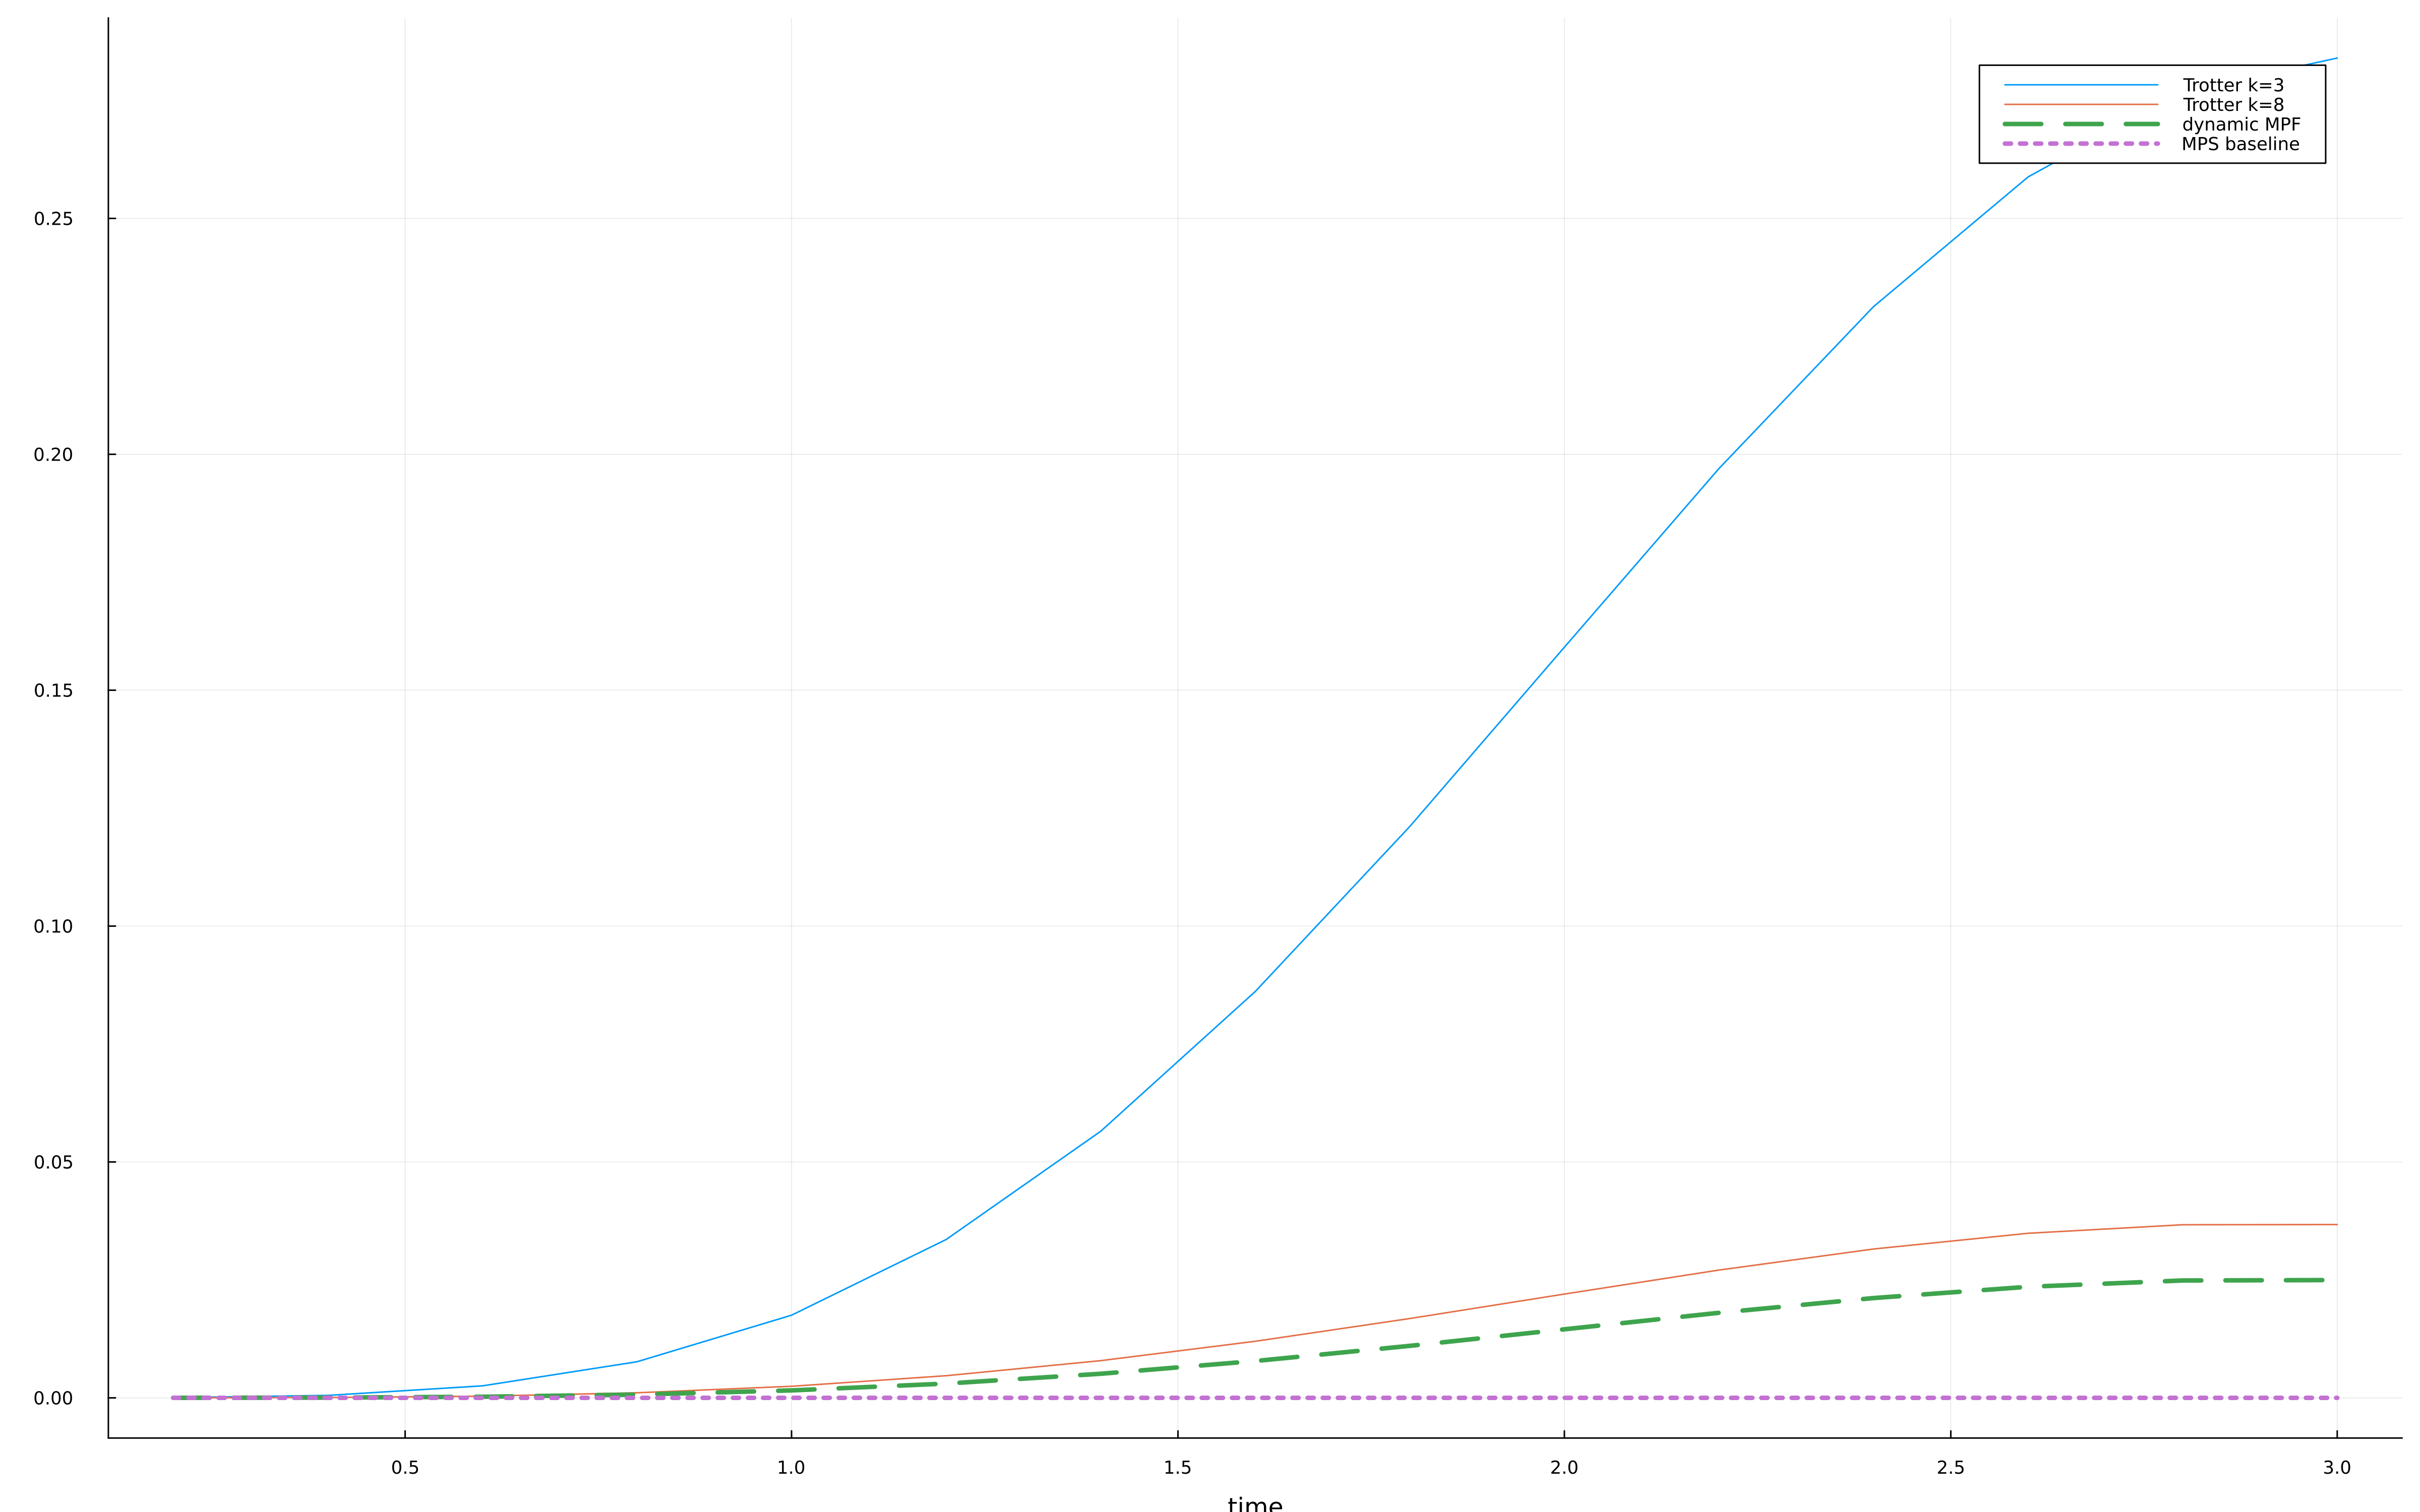

In [16]:
include("plot_figures.jl")
fro_data = frobenius_data_vs_time(
    n, J, 0.2:0.2:3.0, k, k_ref_opt, k_ref_eval, sites, initial_state;
    cutoff_opt, maxdim_opt,
    cutoff_eval, maxdim_eval,
    order, order_ref_opt, order_ref_eval,
    k_mps, maxdim_mps, cutoff_mps, order_mps,
    k_ref_mps, maxdim_ref_mps, cutoff_ref_mps, order_ref_mps
)

plt = plot_frobenius_errors(fro_data, k)
display(plt)

In [45]:
include("dense_sanity_check.jl")
compare_exact_vs_trotter_dense(n, J, t, k, "101")

sanity = sanity_check_L_all(
    n, J, t, k, k_ref_opt, k_ref_eval, sites, initial_state;
    cutoff_opt=cutoff_opt, maxdim_opt=maxdim_opt,
    cutoff_eval=cutoff_eval, maxdim_eval=maxdim_eval,
    order=order, order_ref_opt=order_ref_opt, order_ref_eval=order_ref_eval
)

Dense exact vs dense Trotter amplitudes:
k = 3, amp = 0.9248478381302883 - 0.05158792612456525im, |amp|^2 = 0.8580048378161015
k = 8, amp = 0.9903385027468458 - 0.029407128445250896im, |amp|^2 = 0.9816351292262597
L_dense_corrected = [0.8580048378161015, 0.9816351292262597]
L_middle_out      = [0.8724109219029016, 0.9869238180106297]
L_direct_MPO      = [0.8580048376941495, 0.9816351291840676]


(L_dense_corrected = [0.8580048378161015, 0.9816351292262597], L_middle_out = [0.8724109219029016, 0.9869238180106297], L_direct_MPO = [0.8580048376941495, 0.9816351291840676])

### Observable estimation

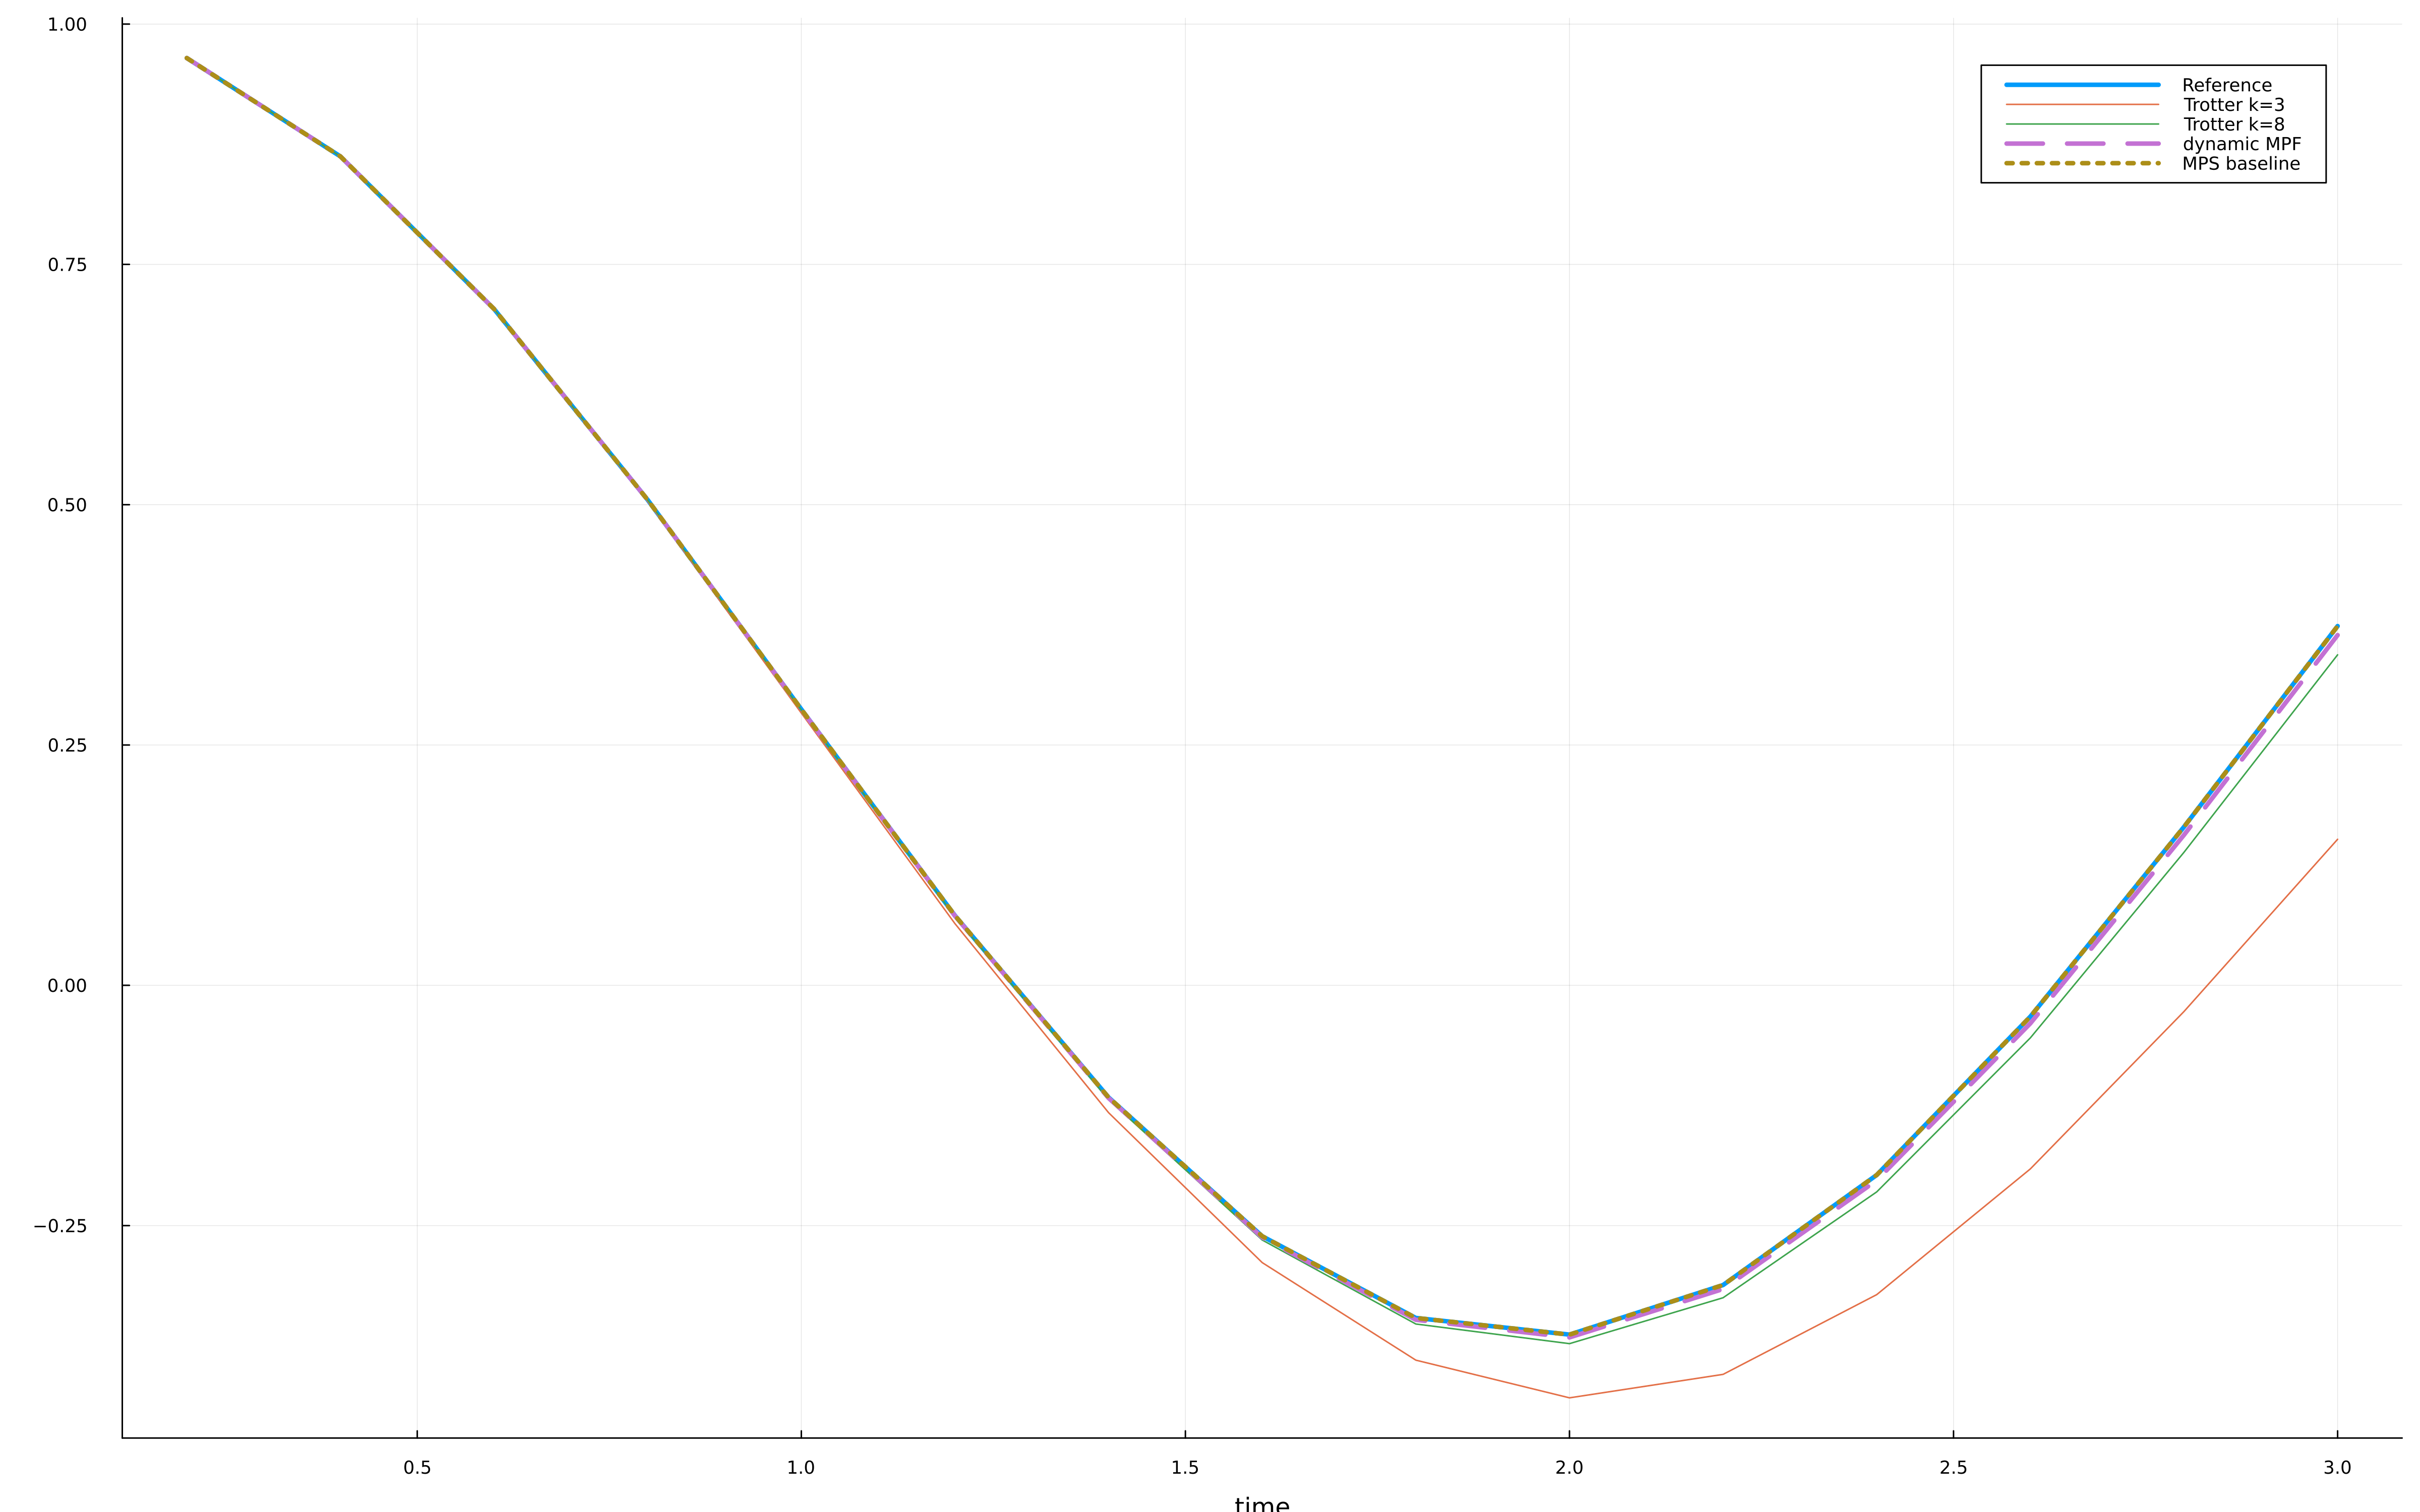

┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

In [18]:
include("observable_estimation.jl")
include("plot_figures.jl")

obs_data = observable_data_vs_time(
    n, J, 0.2:0.2:3.0, k, k_ref_opt, k_ref_eval, sites, initial_state;
    obs_type=:Z,
    i=2,

    cutoff_opt=cutoff_opt,
    maxdim_opt=maxdim_opt,
    order_ref_opt=order_ref_opt,
    order=order,

    cutoff_eval=cutoff_eval,
    maxdim_eval=maxdim_eval,
    order_ref_eval=order_ref_eval,
    k_ref_eval_obs=k_ref_eval,

    cutoff_mps=cutoff_mps,
    maxdim_mps=maxdim_mps,
    order_mps=order_mps,
    k_mps=k_mps,

    cutoff_trot_obs=cutoff_eval,
    maxdim_trot_obs=maxdim_eval,
)

plt = plot_observable_vs_time(obs_data, k; ylabel="⟨Z₂⟩")
display(plt)

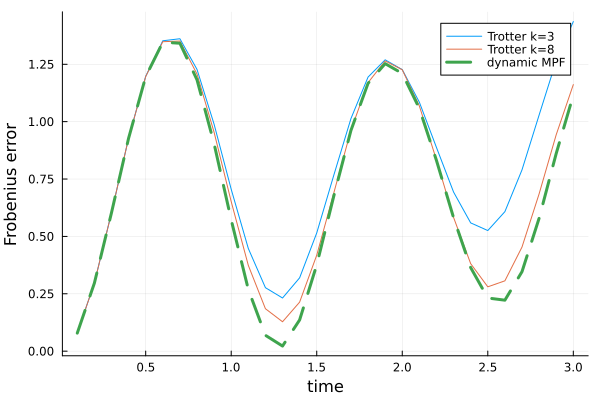

"c:\\Users\\Benjamin\\Desktop\\dmpf_dissipation-1\\figs\\frobenius_errors.pdf"

In [ ]:
include("error_estimation.jl")
times = 0.1:0.1:3.0
ks = [3, 8]


data = frobenius_data_vs_time(, J, times, ks, k_ref_opt, k_ref_eval, sites, initial_state)
plt = plot_frobenius_errors(data, ks)
display(plt)

mkpath("figs")
savefig(plt, "figs/new_implementation_frobenius_errors.png")
savefig(plt, "figs/new_implementation_frobenius_errors.pdf")

Another thing pending to do is the interpretation of each element of the MPOs $F_{ij}$.

In [3]:
for element in F_comp
    print(element.data)
end

ITensor[ITensor ord=3
Dim 1: (dim=2|id=337|"Qubit,Site,n=1")'
Dim 2: (dim=2|id=337|"Qubit,Site,n=1")
Dim 3: (dim=4|id=980|"Link,l=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×4
[:, :, 1] =
     -2.0000000000000178 + 2.569059257801529e-36im  2.0755245855328228e-27 - 9.321580665476716e-24im
 -3.5542490597466236e-22 - 4.208441875055254e-24im     -1.9999999999999902 - 6.205009367927508e-25im

[:, :, 2] =
  -4.840563669763393e-15 - 4.982140578458303e-15im   2.0537035197474474e-16 - 1.3213196499124505e-16im
 -1.0799055269208098e-16 + 1.4329662007287874e-16im   4.840563669763459e-15 + 4.982140578458371e-15im

[:, :, 3] =
   3.70388205818186e-18 + 1.0349511940873397e-17im   4.425868516762766e-16 + 1.8684692859036118e-16im
 -9.472109594561239e-17 + 4.3649634901417676e-16im  -3.703882058181911e-18 - 1.0349511940873538e-17im

[:, :, 4] =
 -1.008709223001384e-18 - 1.4021992128833829e-18im  -3.394144391117315e-17 + 7.71283928717483e-17im
  8.827871572197986e-17 + 2.0639775439086375e-17i

For this, we will contrast the tensor elements of the MPOs with the matrices obtained by computing $F_{ij}$ directly through matrix multiplication.

In [4]:
F_matrix = matrix_F(num_emitters, omega_m, omega_c, g, gamma, kappa, t, k)
using PrettyTables
for element in F_matrix
    pretty_table(real(round.(Matrix(element), digits=4)))
end

┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ Col. 1 │ Col. 2 │ Col. 3 │ Col. 4 │ Col. 5 │ Col. 6 │ Col. 7 │ Col. 8 │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┘
┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ Col. 1 │ Col. 2 │ Col. 3 │ Col. 4 │ 